## Ecuaciones Diferenciales de Segundo Orden en Python

### Oscilador Armonico Simple (Ecuacion Lineal)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [45]:
numPuntos = 1000
tIni = 0
tFin = 30
t = np.linspace(tIni,tFin,numPuntos)
k = 1
m = 1
x_0 = 5
v_0 = 0

In [46]:
def OAS(t,x0,v0,k,m,np):
    x = [x0]
    v = [v0]
    h = t[1]- t[0]
    
    for i in range (1,np):
        v.append(v[i-1] - (h*(k/m)*x[i-1]))
        x.append(x[i-1] + h*v[i])
    
    return x,v

In [47]:
x,v = OAS(t,x_0,v_0,k,m,numPuntos)

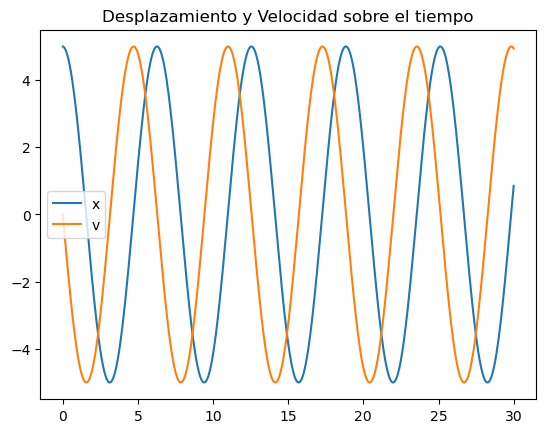

In [48]:
plt.title("Desplazamiento y Velocidad sobre el tiempo")
plt.plot(t,x,label = "x")
plt.plot(t,v,label = "v")
plt.legend()
plt.show()

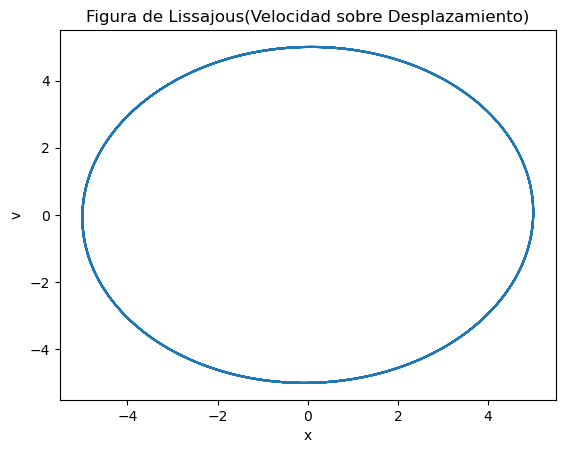

In [49]:
plt.title("Figura de Lissajous(Velocidad sobre Desplazamiento)")
plt.xlabel("x")
plt.ylabel("v")
plt.plot(x,v)
plt.show()

#### Uso Scipy

In [50]:
def OAS2(vals,t,wSquared):
    return np.array([vals[1],-wSquared*vals[0]]) #En valores 1 esta la velocidad y en 0 esta el desplazamiento

In [51]:
h = (tFin - tIni)/(numPuntos-1)
condicionesIniciales = [x_0,v_0]
wSquared = k/m

In [52]:
sol = odeint(OAS2,condicionesIniciales, t, args=(wSquared,))
x = sol[:,0]
v = sol[:,1]

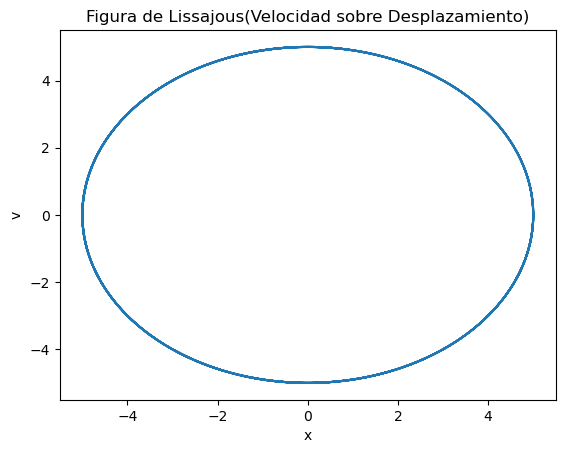

In [53]:
plt.title("Figura de Lissajous(Velocidad sobre Desplazamiento)")
plt.xlabel("x")
plt.ylabel("v")
plt.plot(x,v)
plt.show()

## Oscilador Amortiguado

In [60]:
def OASAmortiguado(vals,t,wSquared,b,m):
    return np.array([vals[1],-wSquared*vals[0]-(b/m)*vals[1]])

In [71]:
b = 0.1
sol = odeint(OASAmortiguado,condicionesIniciales, t, args=(wSquared,b,m))

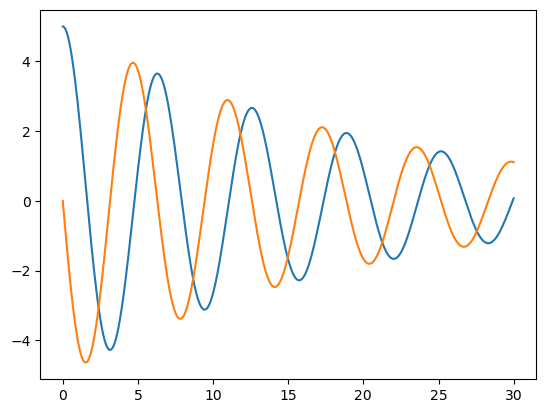

In [72]:
plt.plot(t,sol)
plt.show()

In [63]:
x = sol[:,0]
v = sol[:,1]

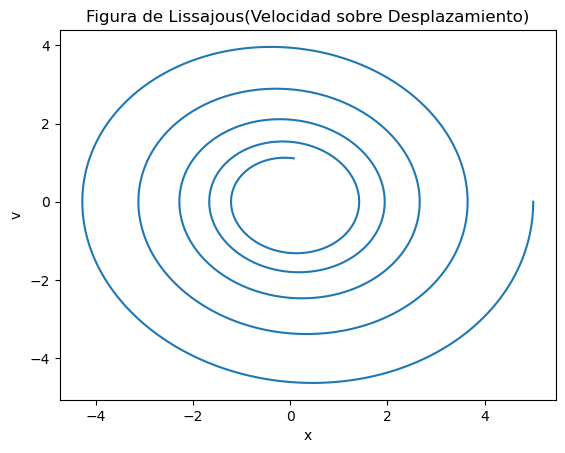

In [64]:
plt.title("Figura de Lissajous(Velocidad sobre Desplazamiento)")
plt.xlabel("x")
plt.ylabel("v")
plt.plot(x,v)
plt.show()

### Oscilador Armonico de Van Der Pol (Ecuacion no lineal)

In [81]:
def OVDP(vals,t,mu):
    return np.array([vals[1],-vals[0]+mu*(1-vals[0]**2)*vals[1]])

In [113]:
mu = 2.15
sol = odeint(OVDP,condicionesIniciales, t, args=(mu,))
x = sol[:,0]
v = sol[:,1]

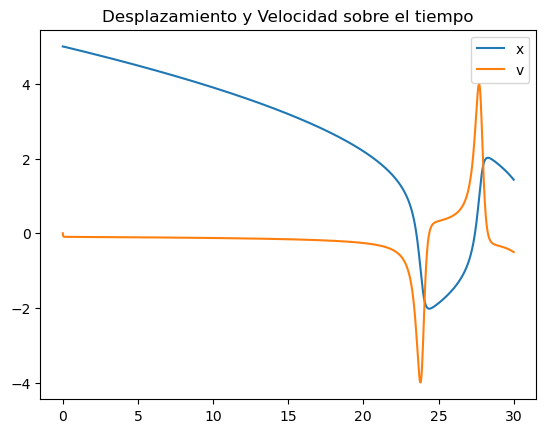

In [114]:
plt.title("Desplazamiento y Velocidad sobre el tiempo")
plt.plot(t,x,label = "x")
plt.plot(t,v,label = "v")
plt.legend()
plt.show()

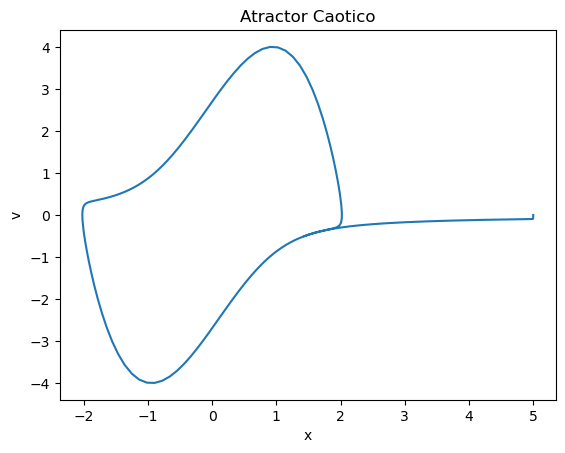

In [115]:
plt.title("Atractor Caotico")
plt.xlabel("x")
plt.ylabel("v")
plt.plot(x,v)
plt.show()